In [1]:

import sys
import os 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import tqdm
import numpy as np
import pandas as pd
import pertpy as pt
import anndata as ad
import scanpy as sc
import scvi
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression


from utils import scanpy_setup, subsample

sc.set_figure_params(dpi=100, frameon=False, facecolor=None)

/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
print(scvi.__version__)
print(pt.__version__)

1.4.1
1.0.5


In [4]:
metrics = ['euclidean', 'spearman_distance', 'mean_absolute_error']  # representative                                                                                                                                                                       
metrics += ['r2_distance', 'pearson_distance', 'mse', 'cosine_distance']  # fast                                                                                                                                                                            
metrics += ['edistance', 'sym_kldiv', 'mmd', 'ks_test', 't_test', 'wasserstein'] # slow                                                                                                                                                                      
metrics += ['classifier_proba', 'classifier_cp', 'kendalltau_distance']  # newly added  

In [5]:
adata = pt.dt.kang_2018()
scanpy_setup(adata)  # log-normalized
sc.pp.highly_variable_genes(adata, subset=True)
adata

/Users/tessagreen/Documents/GitHub/perturbation-metrics/utils.py:33: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(adata, use_highly_variable=True)


AnnData object with n_obs × n_vars = 24673 × 1876
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'

We'll take the pertpy scGen tutorial and tutorial data as an example of evaluating a model using different metrics.

In [6]:
train = adata[~((adata.obs["cell_type"] == "CD4 T cells") &
                    (adata.obs["label"] == "stim"))].copy()
stim_adata = adata[((adata.obs['cell_type'] == 'CD4 T cells') & (adata.obs['label'] == 'stim'))]
ctrl_adata = adata[((adata.obs['cell_type'] == 'CD4 T cells') & (adata.obs['label'] == 'ctrl'))]

In [7]:
pt.tl.Scgen.setup_anndata(train, batch_key="label", labels_key="cell_type")

Predict with pertpy scGen several times, changing the hyperparamters.

In [8]:
preds = {}

In [9]:
model = pt.tl.Scgen(train)
model.train(
    max_epochs=100,
    batch_size=32,
    early_stopping=True,
    early_stopping_patience=25
)

pred, delta = model.predict(
    ctrl_key='ctrl',
    stim_key='stim',
    celltype_to_predict='CD4 T cells'
)
pred.obs['label'] = 'pred'

scgen_pred = subsample(ad.concat([stim_adata, pred]), 5000, 'label')
scgen_pred.layers['lognorm'] = scgen_pred.X

preds['scGen_default'] = scgen_pred

Metal device set to: Apple M3

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB

INFO     Jax module moved to TFRT_CPU_0.Note: Pytorch lightning will show GPU is not being used for the Trainer.   


W0000 00:00:1770743244.760919 25509601 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1770743244.786996 25509601 service.cc:145] XLA service 0x319b36860 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770743244.787169 25509601 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1770743244.790682 25509601 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1770743244.790689 25509601 mps_client.cc:384] XLA backend will use up to 17179410432 bytes on device 0 for SimpleAllocator.
/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/scvi/model/base/_jaxmixin.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machin

Epoch 1/100:   0%|          | 0/100 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:378: You have overridden `transfer_batch_to_device` in `LightningModule` but have passed in a `LightningDataModule`. It will use the implementation from `LightningModule` instance.


Epoch 26/100:  26%|██▌       | 26/100 [04:05<11:39,  9.46s/it, v_num=1, train_loss_step=845, train_loss_epoch=3.4e+3]     
Monitored metric elbo_validation did not improve in the last 25 records. Best score: 444.218. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/Users/tessagreen/Documents/GitHub/perturbation-metrics/utils.py:149: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  groups = adata.obs.groupby(groupby).apply(lambda x: x.sample(n=n_cells, random_state=0, replace=False))
/var/folders/1c/sqv2cjg97gncy4p2xvdsgsfr0000gn/T/ipykernel_74477/2589208844.py:17: ImplicitModificationWarning: Setting element `.layers['lognorm']` of view, initializing view as actual.
  scgen_pred.layers['lognorm'] = scgen_pred.X


In [10]:
model = pt.tl.Scgen(train, n_latent=50, n_layers=1, n_hidden=800)
model.train(
    max_epochs=100,
    batch_size=32,
    early_stopping=True,
    early_stopping_patience=25
)

pred, delta = model.predict(
    ctrl_key='ctrl',
    stim_key='stim',
    celltype_to_predict='CD4 T cells'
)
pred.obs['label'] = 'pred'

scgen_pred = subsample(ad.concat([stim_adata, pred]), 5000, 'label')
scgen_pred.layers['lognorm'] = scgen_pred.X

preds['scGen_shallow'] = scgen_pred

INFO     Jax module moved to TFRT_CPU_0.Note: Pytorch lightning will show GPU is not being used for the Trainer.   


/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/scvi/model/base/_jaxmixin.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/lightning/pyto

Epoch 100/100: 100%|██████████| 100/100 [10:53<00:00,  6.37s/it, v_num=1, train_loss_step=787, train_loss_epoch=2.37e+3]  

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [10:53<00:00,  6.53s/it, v_num=1, train_loss_step=787, train_loss_epoch=2.37e+3]
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/Users/tessagreen/Documents/GitHub/perturbation-metrics/utils.py:149: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  groups = adata.obs.groupby(groupby).apply(lambda x: x.sample(n=n_cells, random_state=0, replace=False))
/var/folders/1c/sqv2cjg97gncy4p2xvdsgsfr0000gn/T/ipykernel_74477/2033271174.py:17: ImplicitModificationWarning: Setting element `.layers['lognorm']` of view, initializing view as actual.
  scgen_pred.layers['lognorm'] = scgen_pred.X


We'll also train a linear regression model on the same task. Of course, we would not expect a linear regression to be able to predict a completely unseen covariate as scGen does (here via pertpy), but for the purposes of this performance comparison, it does not matter.

In [11]:
%%time
def _to_dense(x):
    return x.A if hasattr(x, 'A') else x.toarray()

X = _to_dense(train.X)
y_train = _to_dense(train.X)

X_t = _to_dense(ctrl_adata.X)
y_test = _to_dense(stim_adata.X)

# use a one-hot for ctrl/stim
ohe = OneHotEncoder()

train_labels = train.obs.label.values
test_labels = np.array(['stim']*ctrl_adata.shape[0])

X_train = np.concatenate([
    X,
    ohe.fit_transform(train_labels.reshape(-1, 1)).toarray()
], axis=1)
X_test = np.concatenate([
    X_t,
    ohe.transform(test_labels.reshape(-1, 1)).toarray()
], axis=1)

# train a linear regression
reg = LinearRegression()
reg.fit(X_train, y_train)

CPU times: user 6.59 s, sys: 345 ms, total: 6.94 s
Wall time: 6.67 s


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
reg_pred = pred.copy()
reg_pred.X = reg.predict(X_test)[:reg_pred.shape[0]]  # resize because scGen samples from a distribution
reg_pred = subsample(ad.concat([stim_adata, reg_pred]), 5000, 'label')
reg_pred.layers['lognorm'] = reg_pred.X
preds['linreg'] = reg_pred

/Users/tessagreen/Documents/GitHub/perturbation-metrics/utils.py:149: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  groups = adata.obs.groupby(groupby).apply(lambda x: x.sample(n=n_cells, random_state=0, replace=False))
/var/folders/1c/sqv2cjg97gncy4p2xvdsgsfr0000gn/T/ipykernel_74477/2619672191.py:4: ImplicitModificationWarning: Setting element `.layers['lognorm']` of view, initializing view as actual.
  reg_pred.layers['lognorm'] = reg_pred.X


Examine how the prediction evaluation would look if we used various different metrics. The standard one has been R2. (TODO: there's a bug here in onesided)

In [13]:
dfs = []
missing_metrics = []
for k, model_pred in preds.items():
    perf_dict = {}
    for metric in tqdm.tqdm(metrics):
        try:
            met = pt.tl.Distance(metric=metric, layer_key='lognorm')
        except ValueError:
            missing_metrics.append(metric)
            continue
        # take distance from real to predicted
        try:
            perf_dict[metric] = met.onesided_distances(model_pred, 'label', selected_group='stim', show_progressbar=False, n_jobs=-1)
        except:
            pass
    dfs.append(pd.DataFrame.from_dict(perf_dict, orient='index').add_suffix(f'_{k}'))

perf_df = pd.concat(dfs, axis=1)
perf_df = perf_df[[c for c in perf_df.columns if 'pred' in c]]

if missing_metrics:
    # de-duplicate, keep order
    seen = set()
    unique_missing = [m for m in missing_metrics if not (m in seen or seen.add(m))]
    print('Skipped unsupported metrics:', ', '.join(unique_missing))


 62%|██████▎   | 10/16 [00:38<00:38,  6.39s/it]/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:423: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  return hypotest_fun_in(*args, **kwds)
100%|██████████| 16/16 [00:54<00:00,  3.43s/it]


In [14]:
def plot(df, cols=None):
    if cols:
        df = df[cols].copy()
    else:
        df = df.copy()

    df.index = [' '.join(x.split('_')) for x in df.index]
    df = df.rename({
        'euclidean':'Euclidean',
        'mse':'MSE',
        'mmd':'MMD',
        'edistance':'E-distance',
        'pearson distance': 'Pearson',
        't test': 'T-test',
        'r2 distance': 'R2',
        'ks test': 'KS statistic',
        'kendalltau distance': 'Kendall tau distance',
        'spearman distance': 'Spearman',
        'classifier cp': 'classifier class projection',
        'wasserstein':'Wasserstein',
        'sym_kldiv':'symmetric KL div.'
    })

    df = df.div(df.max(axis=1), axis=0)
    df = 1.01 - df
    
    df.columns = [' '.join(c.split('_')[1:]) for c in df.columns]

    plt.figure(figsize=(3, 8))
    sns.barplot(x='value', y='index', hue='variable', data=pd.melt(df.reset_index(), id_vars='index'))
    plt.legend()
    plt.xlabel(None)
    plt.ylabel(None)
    plt.grid(False)
    plt.show()
#     raise ValueError

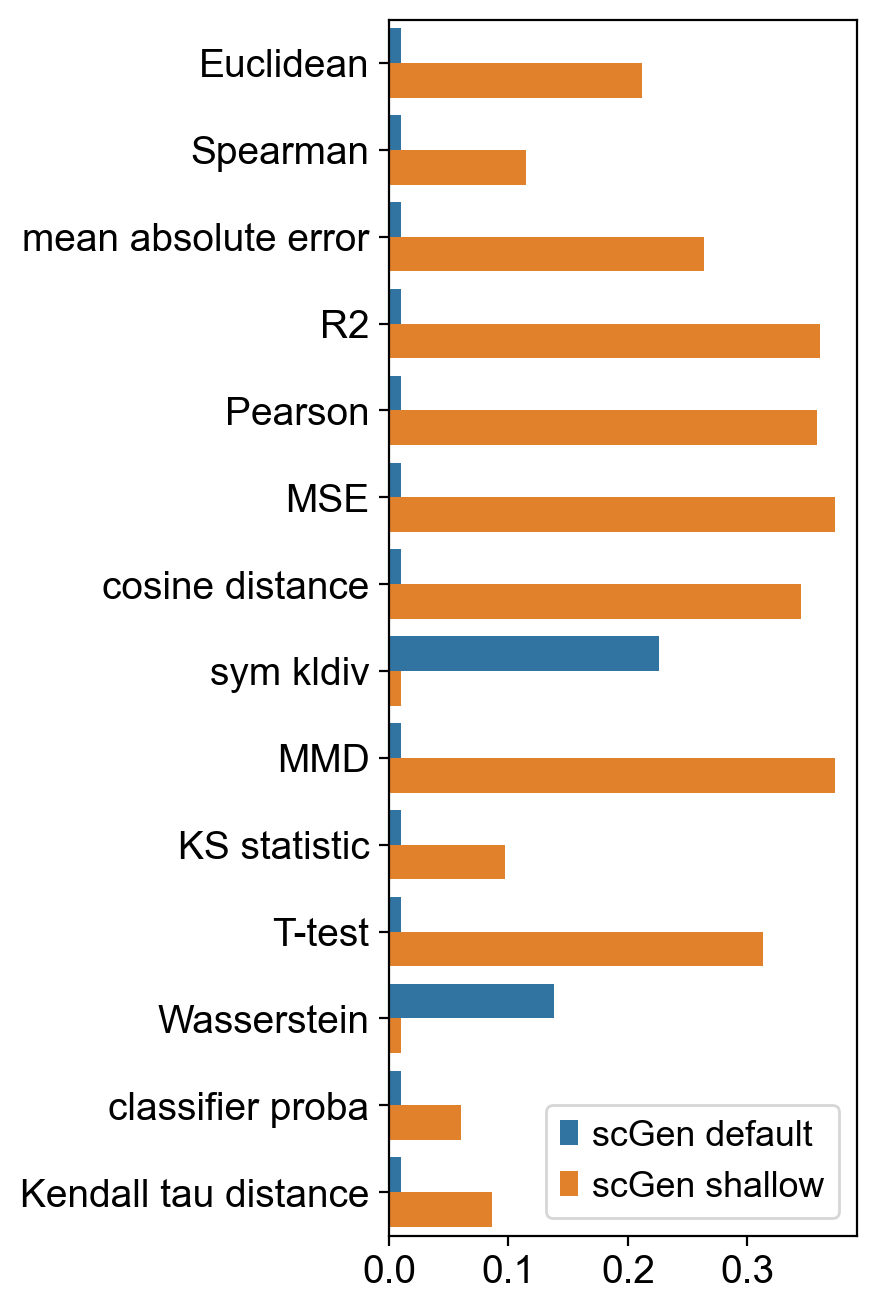

In [15]:
plot(perf_df, ['pred_scGen_default', 'pred_scGen_shallow'])

Also evaluate the prediction using the top 50 DEGs as in the original tutorial.

In [16]:
CD4T = adata[adata.obs.cell_type == 'CD4 T cells']
sc.tl.rank_genes_groups(CD4T, groupby="label", method="wilcoxon")
diff_genes = CD4T.uns["rank_genes_groups"]["names"]["stim"]

/opt/homebrew/Caskroom/mambaforge/base/envs/optdist/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:679: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


In [17]:
dfs = []
for k, model_pred in preds.items():
    perf_dict = {}
    for metric in tqdm.tqdm(metrics):
        met = pt.tl.Distance(metric=metric, layer_key='lognorm')
        # take distance from real to predicted
        try:
            perf_dict[metric] = met.onesided_distances(model_pred[:, diff_genes[:10]], 'label', selected_group='stim', show_progressbar=False, n_jobs=-1)
        except:
            pass
    dfs.append(pd.DataFrame.from_dict(perf_dict, orient='index').add_suffix(f'_{k}'))
deg_perf_df = pd.concat(dfs, axis=1)
deg_perf_df = deg_perf_df[[c for c in deg_perf_df.columns if 'pred' in c]]

100%|██████████| 16/16 [00:10<00:00,  1.59it/s]


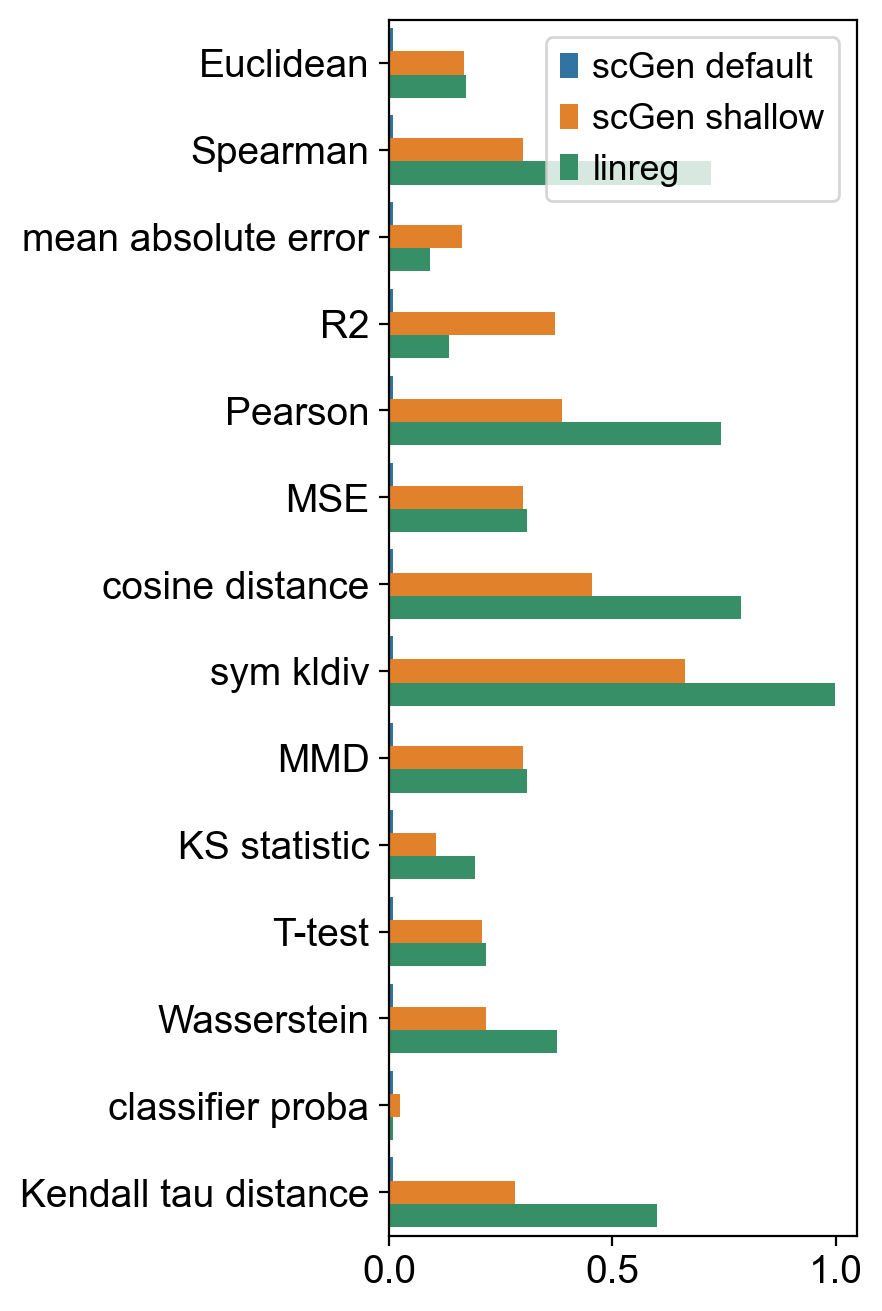

ValueError: 

In [18]:
plot(deg_perf_df)
raise ValueError()